# Chapter 6: Statistical Machine Learning
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(future)
library(patchwork)
library(ranger)
library(rpart.plot)
library(tidymodels)
library(tidyverse)
library(xgboost)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'


Loading required package: rpart



── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──



✔ broom        1.0.12     ✔ recipes      1.3.2 
✔ dials        1.4.3      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.2      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 



── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dials::prune()   masks rpart::prune()
✖ recipes::step()  masks stats::step()



── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ readr     2.2.0     


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ stringr::fixed()    masks recipes::fixed()
✖ dplyr::lag()        masks stats::lag()
✖ readr::spec()       masks yardstick::spec()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Statistical Machine Learning
### K-Nearest Neighbors
#### A Small Example: Predicting Loan Default

In [1]:
loan200 <- read_csv(file.path(DATA_DIR, "loan200.csv"), show_col_types = FALSE) %>%
  mutate(outcome = factor(outcome, levels = c("paid off", "default")))

train_data <- loan200 %>% dplyr::slice(-1)
newloan <- loan200 %>% dplyr::slice(1)
model <- nearest_neighbor(mode = "classification", neighbors = 20,
  weight_func = "rectangular")
knn_model <- workflow() %>%
  add_model(model) %>%
  add_formula(outcome ~ payment_inc_ratio + dti) %>%
  fit(train_data)

knn_pred <- knn_model %>% predict(newloan)
knn_pred

.pred_class
<fct>
paid off


#### Standardization (Normalization, z-Scores)

In [1]:
newloan

outcome,payment_inc_ratio,dti
<fct>,<dbl>,<dbl>
NA,9,22.5


In [1]:
library(FNN)
loan_data <- read_csv(file.path(DATA_DIR, "loan_data.csv.gz"), show_col_types = FALSE) %>%
  select(-c(index, status)) %>%
  mutate(
    across(where(is.character), as.factor),
    outcome = factor(outcome, levels = c("paid off", "default"))
  )

loan_df <- model.matrix(~ -1 + payment_inc_ratio + dti + revol_bal +
    revol_util, data = loan_data)
newloan <- loan_df[1, , drop = FALSE]
loan_df <- loan_df[-1, ]
outcome <- loan_data[-1, ]$outcome
knn_pred <- knn(train = loan_df, test = newloan, cl = outcome, k = 5)
loan_df[attr(knn_pred, "nn.index"), ]

,payment_inc_ratio,dti,revol_bal,revol_util
35537,1.47212,1.46,1686,10.0
33652,3.38178,6.37,1688,8.4
25864,2.36303,1.39,1691,3.5
42954,1.28160,7.14,1684,3.9
43600,4.12244,8.98,1684,7.2


In [1]:
loan_df <- model.matrix(~ -1 + payment_inc_ratio + dti + revol_bal +
    revol_util, data = loan_data)
loan_std <- scale(loan_df)
newloan_std <- loan_std[1, , drop = FALSE]
loan_std <- loan_std[-1, ]
loan_df <- loan_df[-1, ]
outcome <- loan_data[-1, ]$outcome
knn_pred <- knn(train = loan_std, test = newloan_std, cl = outcome, k = 5)
loan_df[attr(knn_pred, "nn.index"), ]

,payment_inc_ratio,dti,revol_bal,revol_util
2081,2.61091,1.03,1218,9.7
1439,2.34343,0.51,278,9.9
30216,2.71200,1.34,1075,8.5
28543,2.39760,0.74,2917,7.4
44738,2.34309,1.37,488,7.2


#### KNN as a Feature Engine

In [1]:
rec <- recipe(outcome ~ dti + revol_bal + revol_util + open_acc +
    delinq_2yrs_zero + pub_rec_zero, data = loan_data)
model <- nearest_neighbor(mode = "classification", neighbors = 20,
  weight_func = "rectangular")
borrow_knn <- workflow() %>%
  add_model(nearest_neighbor(mode = "classification", neighbors = 20)) %>%
  add_recipe(rec) %>%
  fit(loan_data)
borrow_feature <- borrow_knn %>%
  predict(loan_data, type = "prob") %>%
  pluck(".pred_default")
summary(borrow_feature)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.3819  0.5017  0.5001  0.6200  1.0000 

### Tree Models
#### A Simple Example

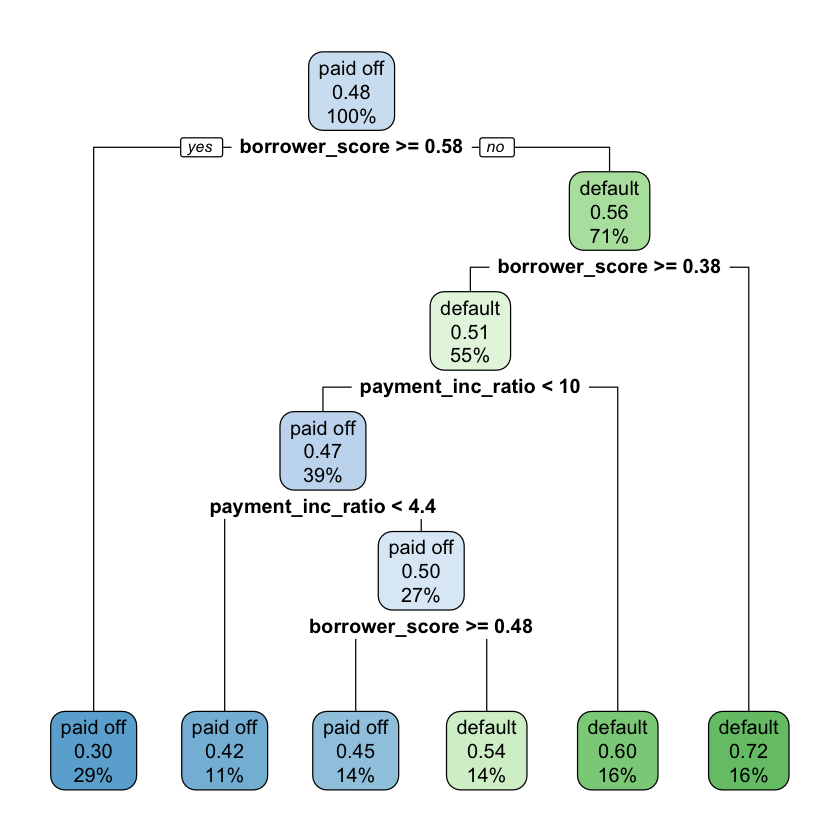

In [1]:
loan3000 <- read_csv(file.path(DATA_DIR, "loan3000.csv"), show_col_types = FALSE) %>%
  mutate(outcome = factor(outcome, levels = c("paid off", "default")))

loan_tree <- decision_tree(mode = "classification", engine = "rpart") %>%
  fit(outcome ~ borrower_score + payment_inc_ratio, data = loan3000)

rpart.plot(loan_tree %>% extract_fit_engine(), roundint = FALSE)

In [1]:
loan_tree

parsnip model object

n= 3000 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 3000 1445 paid off (0.5183333 0.4816667)  
   2) borrower_score>=0.575 878  261 paid off (0.7027335 0.2972665) *
   3) borrower_score< 0.575 2122  938 default (0.4420358 0.5579642)  
     6) borrower_score>=0.375 1639  802 default (0.4893228 0.5106772)  
      12) payment_inc_ratio< 10.42265 1157  547 paid off (0.5272256 0.4727744)  
        24) payment_inc_ratio< 4.42601 334  139 paid off (0.5838323 0.4161677) *
        25) payment_inc_ratio>=4.42601 823  408 paid off (0.5042527 0.4957473)  
          50) borrower_score>=0.475 418  190 paid off (0.5454545 0.4545455) *
          51) borrower_score< 0.475 405  187 default (0.4617284 0.5382716) *
      13) payment_inc_ratio>=10.42265 482  192 default (0.3983402 0.6016598) *
     7) borrower_score< 0.375 483  136 default (0.2815735 0.7184265) *

### Bagging and the Random Forest
#### Random Forest

In [1]:
rf <- rand_forest(mode = "classification") %>%
  set_engine("ranger", seed = 123) %>%
  fit(outcome ~ borrower_score + payment_inc_ratio, data = loan3000)
rf

parsnip model object

Ranger result

Call:
 ranger::ranger(x = maybe_data_frame(x), y = y, seed = ~123, num.threads = 1,      verbose = FALSE, probability = TRUE) 

Type:                             Probability estimation 
Number of trees:                  500 
Sample size:                      3000 
Number of independent variables:  2 
Mtry:                             1 
Target node size:                 10 
Variable importance mode:         none 
Splitrule:                        gini 
OOB prediction error (Brier s.):  0.2300053 

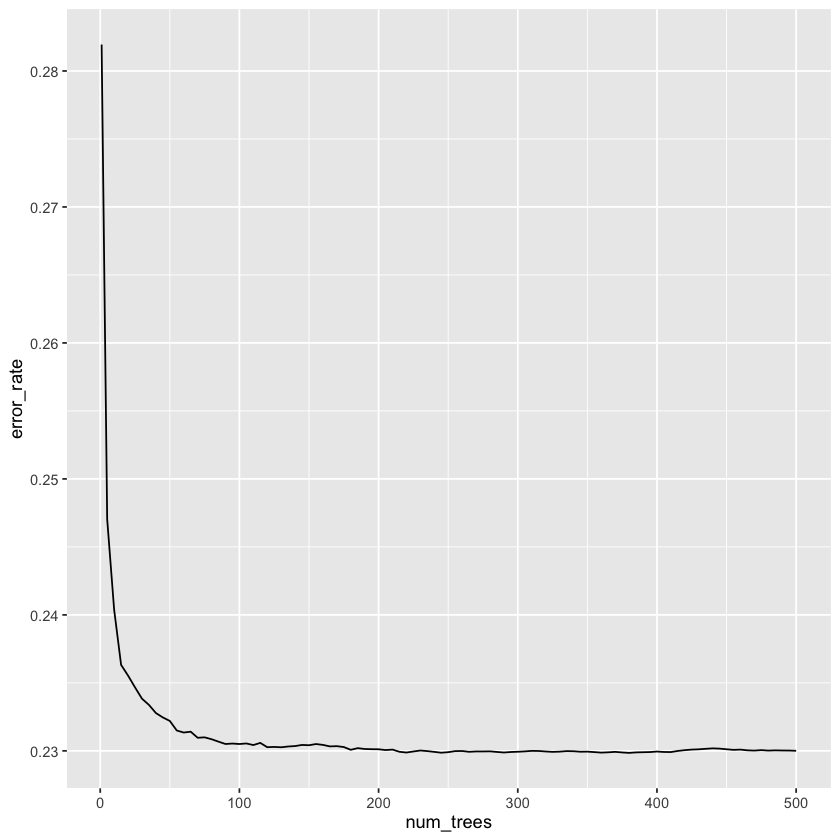

In [1]:
num_trees <- c(1, seq(5, 500, 5))
oob_scores <- c()
for (trees in num_trees) {
  rf <- rand_forest(mode = "classification", trees = trees) %>%
    set_engine("ranger", seed = 123) %>%
    fit(outcome ~ borrower_score + payment_inc_ratio, data = loan3000)
  oob_scores <- c(oob_scores, (rf %>% extract_fit_engine())$prediction.error)
}
error_df <- tibble(error_rate = oob_scores, num_trees = num_trees)
ggplot(error_df, aes(x = num_trees, y = error_rate)) +
  geom_line()

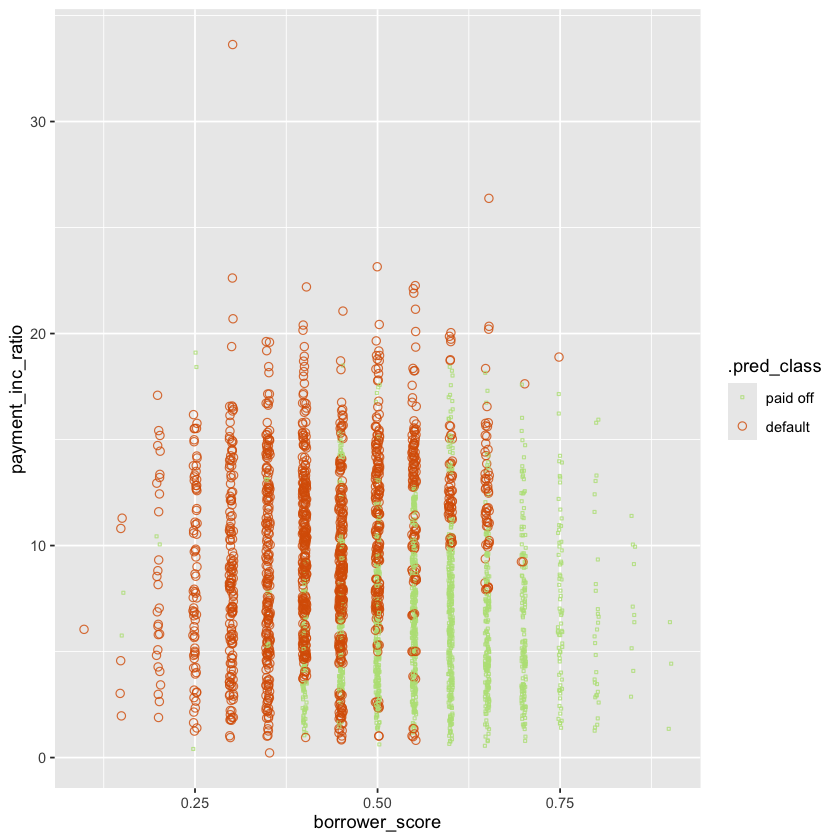

In [1]:
rf_df <- augment(rf, loan3000)
ggplot(data = rf_df, aes(x = borrower_score, y = payment_inc_ratio,
    shape = .pred_class, color = .pred_class, size = .pred_class)) +
  geom_jitter(alpha = 0.8, height = 0, width = 0.003) +
  scale_color_manual(values = c("paid off" = "#b8e186", "default" = "#d95f02")) +
  scale_shape_manual(values = c("paid off" = 0, "default" = 1)) +
  scale_size_manual(values = c("paid off" = 0.5, "default" = 2))

#### Variable Importance

In [1]:
rf_all <- rand_forest(mode = "classification") %>%
  set_engine("ranger", seed = 123, importance = "impurity") %>%
  fit(outcome ~ ., data = loan_data)
rf_all

parsnip model object

Ranger result

Call:
 ranger::ranger(x = maybe_data_frame(x), y = y, seed = ~123, importance = ~"impurity",      num.threads = 1, verbose = FALSE, probability = TRUE) 

Type:                             Probability estimation 
Number of trees:                  500 
Sample size:                      45342 
Number of independent variables:  18 
Mtry:                             4 
Target node size:                 10 
Variable importance mode:         impurity 
Splitrule:                        gini 
OOB prediction error (Brier s.):  0.2123043 

In [1]:
rf_permutation <- rand_forest(mode = "classification") %>%
  set_engine("ranger", seed = 123, importance = "permutation") %>%
  fit(outcome ~ ., data = loan_data)

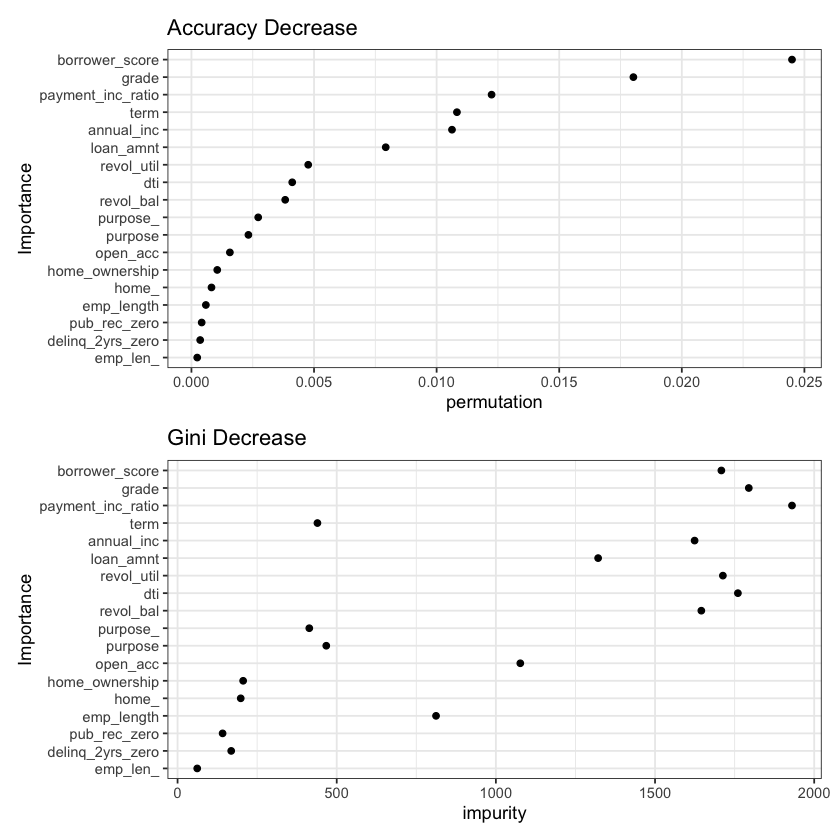

In [1]:
varimp_gini <- importance(rf_all %>% extract_fit_engine())
varimp_perm <- importance(rf_permutation %>% extract_fit_engine())
df <- tibble(
  predictor = names(varimp_gini),
  impurity = varimp_gini,
  permutation = varimp_perm
)
g1 <- ggplot(df, aes(x = permutation, y = reorder(predictor, permutation))) +
  geom_point() +
  labs(y = "Importance", title = "Accuracy Decrease")
g2 <- ggplot(df, aes(x = impurity, y = reorder(predictor, permutation))) +
  geom_point() +
  labs(y = "Importance", title = "Gini Decrease")
(g1 + theme_bw()) / (g2 + theme_bw())

### Boosting
#### XGBoost

In [1]:
xgb <- boost_tree(mode = "classification",
  trees = 100, learn_rate = 0.1, sample_size = 0.63) %>%
  fit(outcome ~ borrower_score + payment_inc_ratio, data = loan3000)

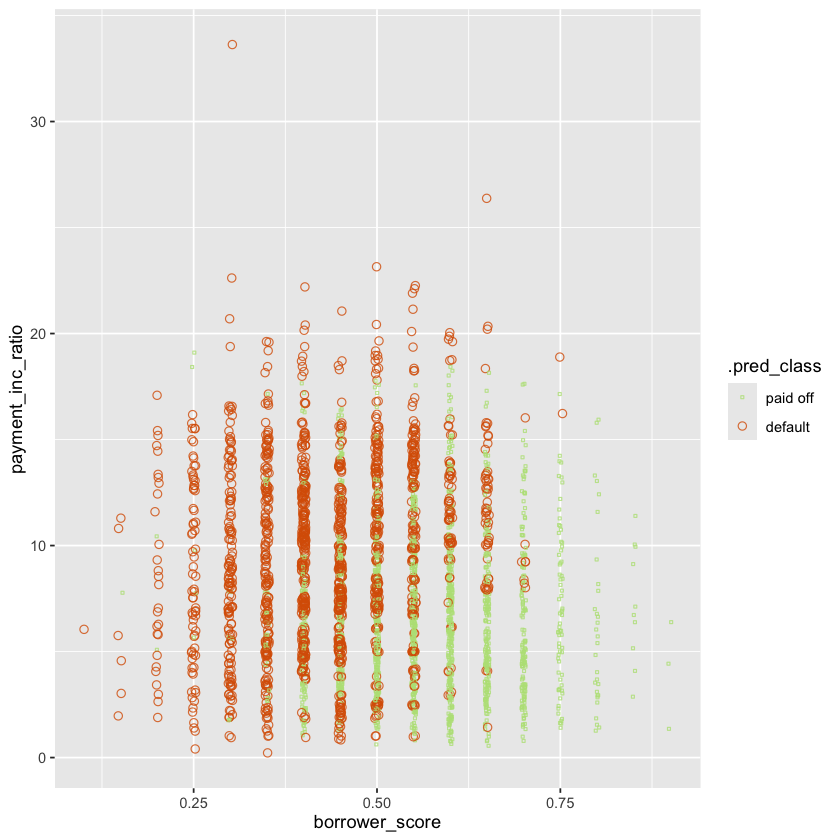

In [1]:
xgb_df <- augment(xgb, loan3000)
ggplot(data = xgb_df, aes(x = borrower_score, y = payment_inc_ratio,
    color = .pred_class, shape = .pred_class, size = .pred_class)) +
  geom_jitter(alpha = 0.8, height = 0, width = 0.003) +
  scale_color_manual(values = c("paid off" = "#b8e186", "default" = "#d95f02")) +
  scale_shape_manual(values = c("paid off" = 0, "default" = 1)) +
  scale_size_manual(values = c("paid off" = 0.5, "default" = 2))

#### Regularization: Avoiding Overfitting

In [1]:
set.seed(400820)
loan_split <- initial_split(loan_data, prop = 0.75)
train_data <- training(loan_split)
test_data <- testing(loan_split)
train_x <- data.matrix(train_data %>% select(-outcome))
train_y <- factor(train_data$outcome, levels = c("paid off", "default"))
test_x <- data.matrix(test_data %>% select(-outcome))
test_y <- factor(test_data$outcome, levels = c("paid off", "default"))

xgb_default <- xgboost(x = train_x, y = train_y,
  objective = "binary:logistic", nrounds = 250, verbosity = 1,
  eval_metric = "error")

pred_default <- predict(xgb_default, test_x)
error_default <- abs((as.numeric(test_y) - 1) - pred_default) > 0.5
attributes(xgb_default)$evaluation_log[250, ]
mean(error_default)

[1]	train-error:0.336646 
[2]	train-error:0.329677 
[3]	train-error:0.326031 
[4]	train-error:0.321355 
[5]	train-error:0.320032 
[6]	train-error:0.317356 
[7]	train-error:0.315915 
[8]	train-error:0.313739 
[9]	train-error:0.312445 
[10]	train-error:0.311386 
[11]	train-error:0.308740 
[12]	train-error:0.306769 
[13]	train-error:0.303946 
[14]	train-error:0.302711 
[15]	train-error:0.299712 
[16]	train-error:0.298653 
[17]	train-error:0.297065 
[18]	train-error:0.296859 
[19]	train-error:0.294183 
[20]	train-error:0.293419 
[21]	train-error:0.292801 
[22]	train-error:0.290508 
[23]	train-error:0.290213 
[24]	train-error:0.288390 
[25]	train-error:0.288008 
[26]	train-error:0.287067 
[27]	train-error:0.284656 
[28]	train-error:0.283450 
[29]	train-error:0.281597 
[30]	train-error:0.280421 
[31]	train-error:0.279627 
[32]	train-error:0.278304 
[33]	train-error:0.275745 
[34]	train-error:0.274540 
[35]	train-error:0.274246 
[36]	train-error:0.273716 
[37]	train-error:0.273099 
[38]	train

iter,train_error
<dbl>,<dbl>
250,0.1087749


[1] 0.3591214

In [1]:
xgb_penalty <- xgboost(x = train_x, y = train_y,
  learning_rate = 0.1, subsample = 0.63, reg_lambda = 1000,
  objective = "binary:logistic", nrounds = 250, verbosity = 1,
  eval_metric = "error")
pred_penalty <- predict(xgb_penalty, test_x)
error_penalty <- abs((as.numeric(test_y) - 1) - pred_penalty) > 0.5
attributes(xgb_penalty)$evaluation_log[250, ]
mean(error_penalty)

[1]	train-error:0.363730 
[2]	train-error:0.344116 
[3]	train-error:0.342969 
[4]	train-error:0.340116 
[5]	train-error:0.338646 
[6]	train-error:0.334882 
[7]	train-error:0.336411 
[8]	train-error:0.336588 
[9]	train-error:0.336911 
[10]	train-error:0.336999 
[11]	train-error:0.335588 
[12]	train-error:0.337176 
[13]	train-error:0.335794 
[14]	train-error:0.334529 
[15]	train-error:0.335676 
[16]	train-error:0.334147 
[17]	train-error:0.334323 
[18]	train-error:0.333970 
[19]	train-error:0.334323 
[20]	train-error:0.334706 
[21]	train-error:0.334118 
[22]	train-error:0.333765 
[23]	train-error:0.333118 
[24]	train-error:0.332765 
[25]	train-error:0.331294 
[26]	train-error:0.331294 
[27]	train-error:0.331353 
[28]	train-error:0.331324 
[29]	train-error:0.331236 
[30]	train-error:0.330559 
[31]	train-error:0.330530 
[32]	train-error:0.329854 
[33]	train-error:0.328971 
[34]	train-error:0.329060 
[35]	train-error:0.328530 
[36]	train-error:0.329089 
[37]	train-error:0.328471 
[38]	train

iter,train_error
<dbl>,<dbl>
250,0.31021


[1] 0.3300988

In [1]:
error_default <- rep(0, 249)
error_penalty <- rep(0, 249)
for (ntree_limit in 1:249) {
  iteration_range <- c(1, ntree_limit + 1)
  pred_def <- predict(xgb_default, test_x, iteration_range = iteration_range)
  error_default[ntree_limit] <- mean(abs(as.numeric(test_y)-1-pred_def) >= 0.5)
  pred_pen <- predict(xgb_penalty, test_x, iteration_range = iteration_range)
  error_penalty[ntree_limit] <- mean(abs(as.numeric(test_y)-1-pred_pen) >= 0.5)
}

In [1]:
knitr::opts_chunk$set(cache = FALSE)

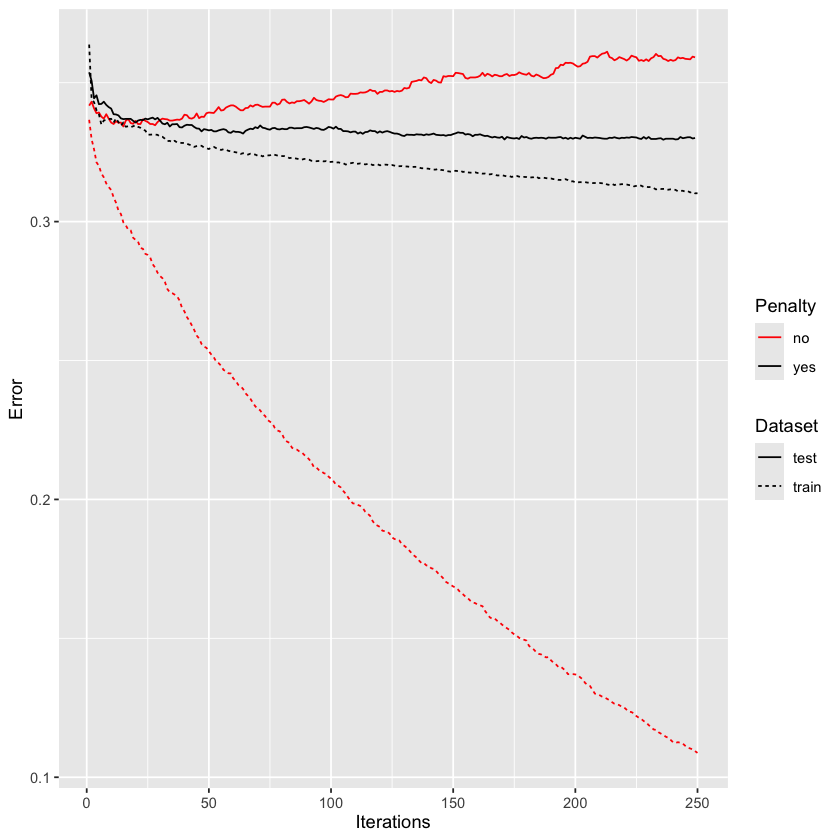

In [1]:
errors <- bind_rows(
  tibble(Iterations = 1:250, Error = attributes(xgb_default)$evaluation_log$train_error,
    Dataset = "train", Penalty = "no"),
  tibble(Iterations = 1:249, Error = error_default,
    Dataset = "test", Penalty = "no"),
  tibble(Iterations = 1:250, Error = attributes(xgb_penalty)$evaluation_log$train_error,
    Dataset = "train", Penalty = "yes"),
  tibble(Iterations = 1:249, Error = error_penalty,
    Dataset = "test", Penalty = "yes"),
)
ggplot(errors, aes(x = Iterations, y = Error, color = Penalty,
    linetype = Dataset)) +
  geom_line() +
  scale_color_manual(values = c("red", "black"))

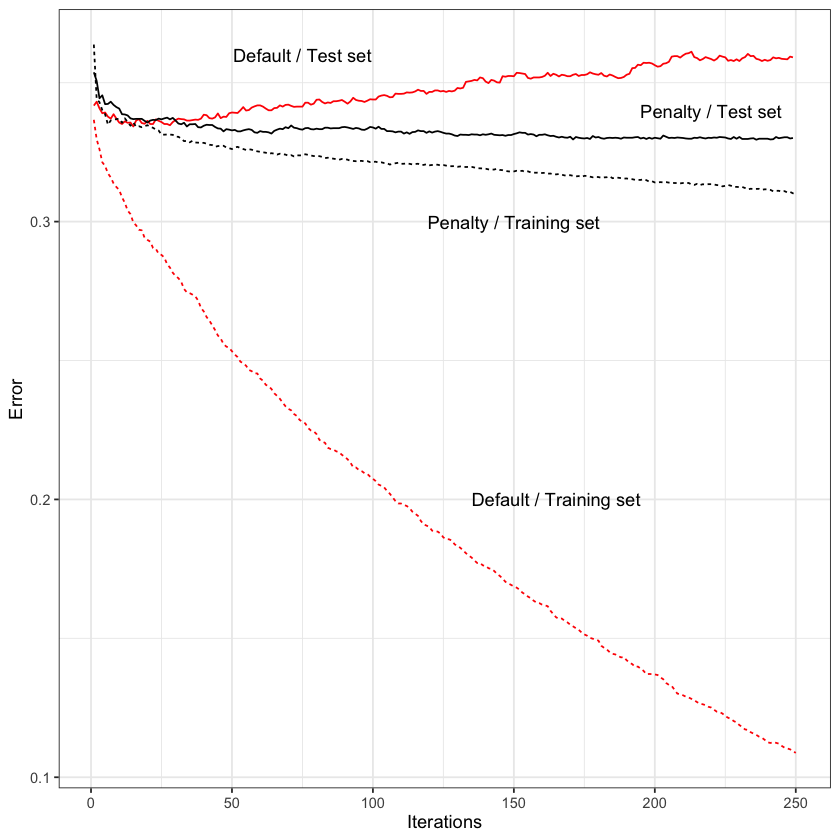

In [1]:
last_plot()  +
  theme_bw() +
  annotate("text", 165, 0.2, label="Default / Training set") +
  annotate("text", 150, 0.3, label="Penalty / Training set") +
  annotate("text", 220, 0.34, label="Penalty / Test set") +
  annotate("text", 75, 0.36, label="Default / Test set") +
  theme(legend.position = "none")

In [1]:
knitr::opts_chunk$set(cache = TRUE)

#### Hyperparameters and Cross-Validation

In [1]:
set.seed(1234)
resamples <- vfold_cv(loan_data, v = 5)
grid <- crossing(
  tree_depth = c(3, 6, 12),
  learn_rate = c(0.1, 0.5, 0.9),
)

In [1]:
plan(multisession, workers = parallel::detectCores(logical = FALSE))

rec <- recipe(outcome ~ ., data = loan_data) %>%
  step_dummy(all_nominal_predictors())
model <- boost_tree(mode = "classification",
  tree_depth = tune(), learn_rate = tune())

wf <- workflow() %>%
  add_model(model) %>%
  add_recipe(rec)

model_cv <- tune_grid(wf, resamples, grid = grid)

In [1]:
collect_metrics(model_cv) %>%
  filter(.metric == "accuracy") %>%
  mutate(error_rate = round(100 * (1 - mean), 2)) %>%
  select(c(tree_depth, learn_rate, error_rate)) %>%
  arrange(error_rate)

tree_depth,learn_rate,error_rate
<dbl>,<dbl>,<dbl>
3,0.5,33.28
3,0.9,33.52
6,0.1,33.53
6,0.5,33.81
3,0.1,34.20
12,0.1,34.69
6,0.9,34.86
12,0.5,36.43
12,0.9,38.78


# Supplementary Material
## Figure 6-2. KNN prediction of loan default using two variables: debt-to-income ratio and loan-payment-to-income ratio

In [1]:
train_data <- loan200 %>%
  dplyr::slice(-1)
newloan <- loan200 %>%
  dplyr::slice(1) %>%
  select(payment_inc_ratio, dti)

# The knn function from the class package gives us access to a list of the nearest
# neighbors and their distances via attributes "nn.index" and "nn.dist"
knn_pred <- knn(train = train_data[c("payment_inc_ratio", "dti")], test = newloan,
  cl = train_data$outcome, k = 20)

nearest_points <- loan200[c(attr(knn_pred, "nn.index") + 1), ]
nearest_points
dist <- attr(knn_pred, "nn.dist")

circle_coordinates <- function(center = c(0, 0), r = 1, npoints = 100) {
  tt <- seq(0, 2 * pi, length.out = npoints - 1)
  xx <- center[1] + r * cos(tt)
  yy <- center[2] + r * sin(tt)
  return(data.frame(x = c(xx, xx[1]), y = c(yy, yy[1])))
}

circle_df <- circle_coordinates(center = unlist(newloan), r = max(dist),
  npoints = 201)

outcome,payment_inc_ratio,dti
<fct>,<dbl>,<dbl>
default,8.65527,22.23
default,9.05778,21.62
paid off,9.44925,23.30
default,8.70942,24.13
default,9.43396,24.15
default,8.02887,20.86
default,6.91886,22.47
paid off,9.64200,20.17
paid off,7.70160,24.57


In [1]:
# set first entry as target - requires adding additional level to factor
levels(loan200$outcome) <- c(levels(loan200$outcome), "newloan")
loan200[1, "outcome"] <- "newloan"
head(loan200)
levels(nearest_points$outcome)

outcome,payment_inc_ratio,dti
<fct>,<dbl>,<dbl>
newloan,9.00000,22.50
default,5.46933,21.33
paid off,6.90294,8.97
paid off,11.14800,1.83
default,3.72120,10.81
paid off,1.89923,11.34


[1] "paid off" "default"

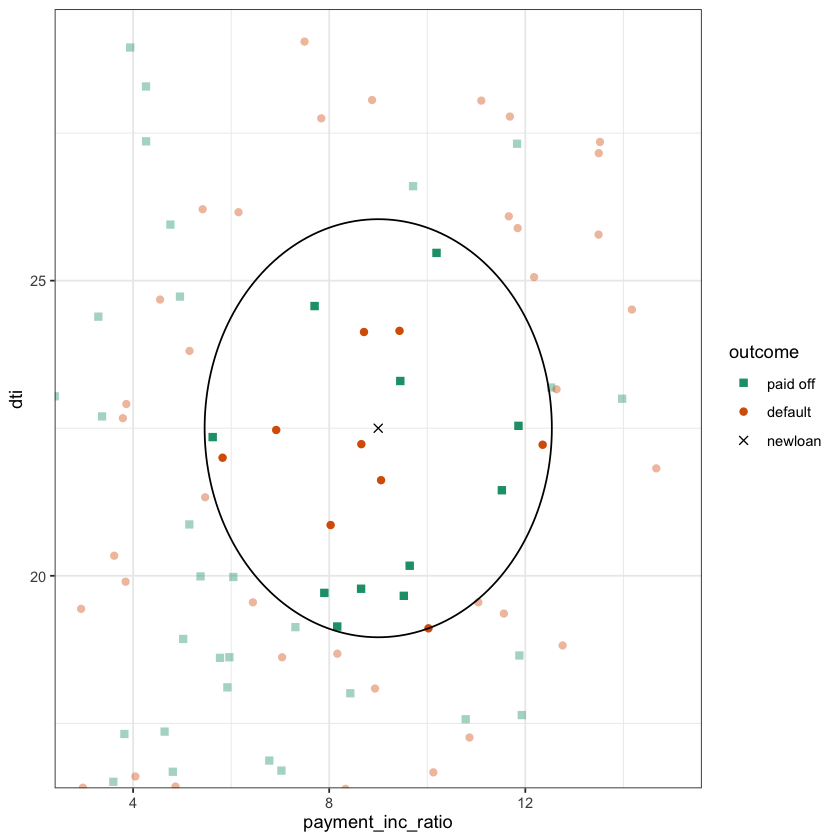

In [1]:
graph <- ggplot(data = loan200, aes(x = payment_inc_ratio, y = dti, color = outcome)) +
  geom_point(aes(shape = outcome), size = 2, alpha = 0.4) +
  geom_point(data = nearest_points, aes(shape = outcome), size = 2) +
  geom_point(data = loan200[1, ], aes(shape = outcome), size = 2) +
  scale_shape_manual(values = c(15, 16, 4)) +
  scale_color_manual(values = c("paid off" = "#1b9e77", "default" = "#d95f02", "newloan" = "black")) +
  geom_path(data = circle_df, aes(x = x, y = y), color = "black") +
  coord_cartesian(xlim = c(3, 15), ylim = c(17, 29)) +
  theme_bw()
graph

## Figure 6-4. The first five rules for a simple tree model fit to the loan data

In [1]:
## Figure 6-4: View of partition rules
r_tree <- tibble(
  x1 = c(0.575, 0.375, 0.375, 0.375, 0.475),
  x2 = c(0.575, 0.375, 0.575, 0.575, 0.475),
  y1 = c(0, 0, 10.42, 4.426, 4.426),
  y2 = c(25, 25, 10.42, 4.426, 10.42),
  rule_number = factor(c(1, 2, 3, 4, 5)))
r_tree <- as.data.frame(r_tree)

rules <- tibble(
  x = c(0.575, 0.375, 0.4, 0.4, 0.475),
  y = c(24, 24, 10.42, 4.426, 9.42),
  rule_number = factor(c(1, 2, 3, 4, 5))
)

labs <- tibble(
  x = c(
    0.575 + (1 - 0.575) / 2,
    0.375 / 2,
    (0.375 + 0.575) / 2,
    (0.375 + 0.575) / 2,
    (0.475 + 0.575) / 2,
    (0.375 + 0.475) / 2
  ),
  y = c(
    12.5,
    12.5,
    10.42 + (25 - 10.42) / 2,
    4.426 / 2,
    4.426 + (10.42 - 4.426) / 2,
    4.426 + (10.42 - 4.426) / 2
  ),
  decision = factor(c(
    "paid off",
    "default",
    "default",
    "paid off",
    "paid off",
    "default"
  ))
)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Warning message:
“No shared levels found between `names(values)` of the manual scale and the data's shape values.”


Warning message:
“Duplicated `override.aes` is ignored.”


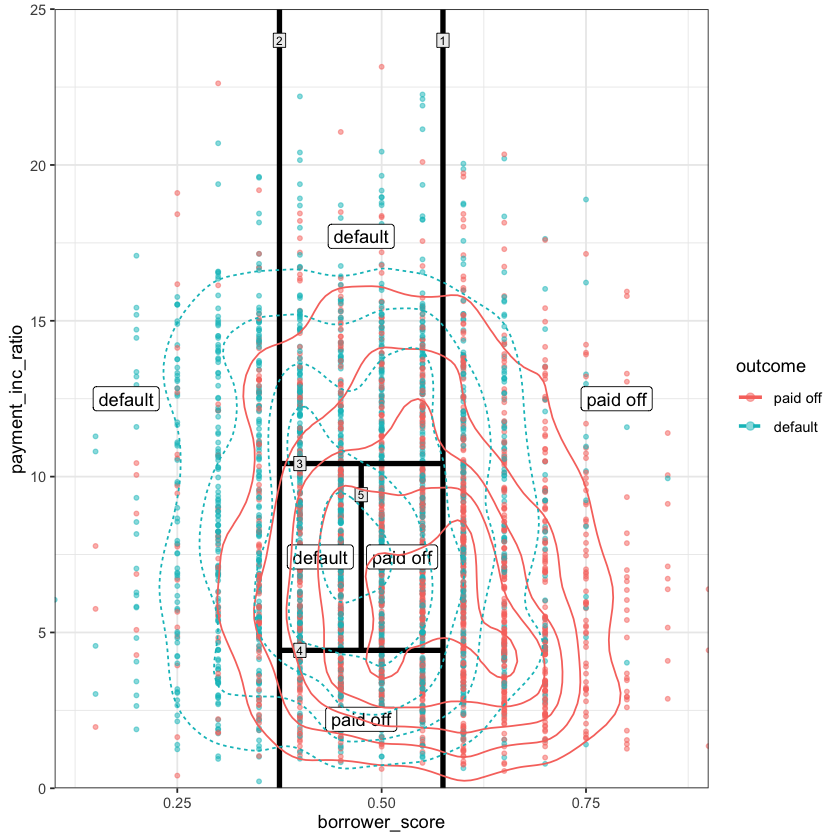

In [1]:
shift <- 0.004
shift <- 0
graph <- loan3000 %>%
  #  mutate(borrower_score = ifelse(outcome == "paid off", borrower_score + shift, borrower_score - shift)) %>%
  mutate(
    borrower_score = borrower_score + rnorm(dim(loan3000)[1], sd = 2 * shift)
  ) %>%
  ggplot(aes(x = borrower_score, y = payment_inc_ratio)) +
    geom_point(aes(color = outcome, size = outcome), alpha = 0.5) +
    # scale_color_manual(values = c("paid off" = "#7fbc41", "default" = "#d95f02")) +
    scale_shape_manual(values = c("paid off" = 0, "default" = 1)) +
    scale_size_manual(values = c("paid off" = 1, "default" = 1)) +
    geom_segment(data = r_tree, aes(x = x1, y = y1, xend = x2, yend = y2), size = 1.5) +
    guides(color = guide_legend(override.aes = list(size = 1.5)),
      linetype = guide_legend(keywidth = 3, override.aes = list(size = 1))) +
    scale_x_continuous(expand = c(0, 0)) +
    scale_y_continuous(expand = c(0, 0)) +
    coord_cartesian(ylim = c(0, 25)) +
    geom_label(data = labs, aes(x = x, y = y, label = decision)) +
    geom_label(data = rules, aes(x = x, y = y, label = rule_number),
      size = 2.5, fill = "#eeeeee",
      label.r = unit(0, "lines"), label.padding = unit(0.2, "lines")) +
    guides(color = guide_legend(override.aes = list(size = 2))) +
    stat_density_2d(aes(linetype = outcome, color = outcome),  
    # variation geom = "polygon",
    # variation aes(alpha = 0.1 * ..level.., fill = outcome),
                    bins = 6)  +
    theme_bw()
graph

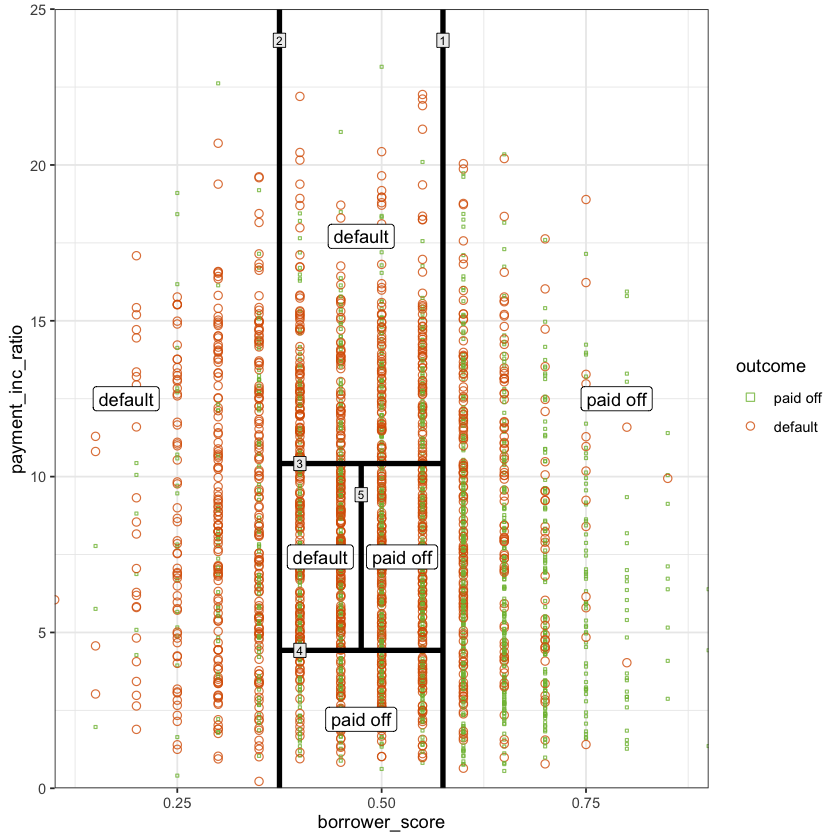

In [1]:
graph <- ggplot(data = loan3000, aes(x = borrower_score, y = payment_inc_ratio)) +
  geom_point(aes(color = outcome, shape = outcome, size = outcome), alpha = 0.8) +
  scale_color_manual(values = c("paid off" = "#7fbc41", "default" = "#d95f02")) +
  scale_shape_manual(values = c("paid off" = 0, "default" = 1)) +
  scale_size_manual(values = c("paid off" = 0.5, "default" = 2)) +
  geom_segment(data = r_tree, aes(x = x1, y = y1, xend = x2, yend = y2), size = 1.5) +
  guides(color = guide_legend(override.aes = list(size = 1.5)),
    linetype = guide_legend(keywidth = 3, override.aes = list(size = 1))) +
  scale_x_continuous(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  coord_cartesian(ylim = c(0, 25)) +
  geom_label(data = labs, aes(x = x, y = y, label = decision)) +
  geom_label(data = rules, aes(x = x, y = y, label = rule_number),
    size = 2.5, fill = "#eeeeee",
    label.r = unit(0, "lines"), label.padding = unit(0.2, "lines")) +
  guides(color = guide_legend(override.aes = list(size = 2))) +
  theme_bw()
graph

## Figure 6-5. Gini impurity and entropy measures

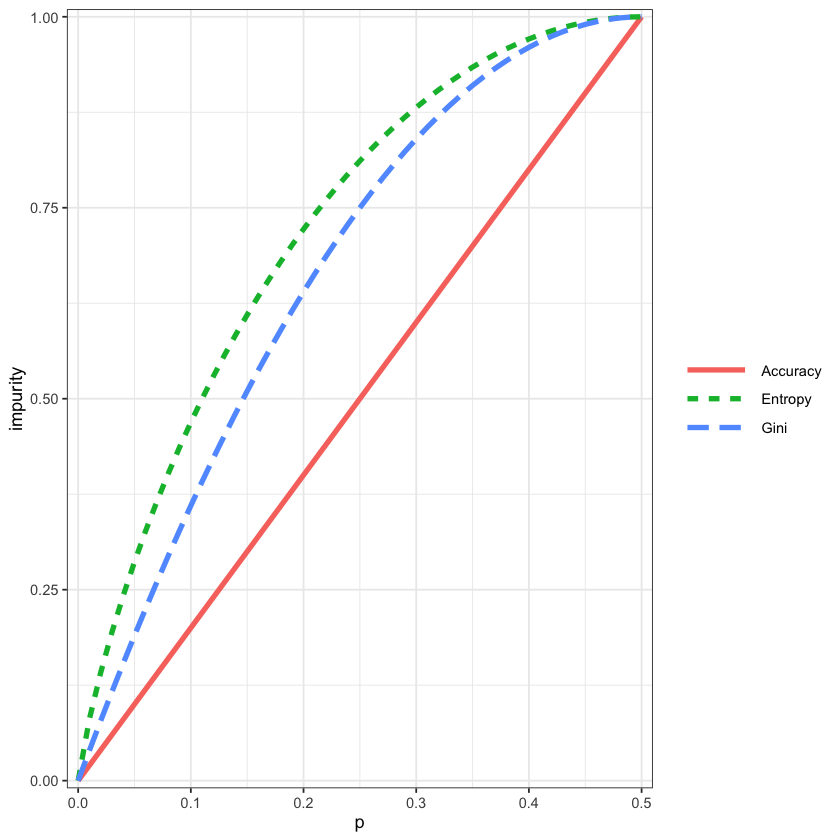

In [1]:
info <- function(x) {
  info <- ifelse(x == 0, 0, -x * log2(x) - (1 - x) * log2(1 - x))
  return(info)
}

gini <- function(x) {
  return(x * (1 - x))
}

x <- 0:50 / 100
impure <- bind_rows(
  tibble(p = x, impurity = 2 * x, type = "Accuracy"),
  tibble(p = x, impurity = gini(x) / gini(0.5) * info(0.5), type = "Gini"),
  tibble(p = x, impurity = info(x), type = "Entropy")
)

graph <- ggplot(data = impure, aes(x = p, y = impurity, linetype = type, color = type)) +
  geom_line(size = 1.5) +
  guides(linetype = guide_legend(keywidth = 3, override.aes = list(size = 1))) +
  scale_x_continuous(expand = c(0, 0.01)) +
  scale_y_continuous(expand = c(0, 0.01)) +
  theme_bw() +
  theme(legend.title = element_blank())
graph